
<center>

## Title:  Solving  Kepler's equation using the Newton-Raphson method 
#### Name: Faraz Khan
#### Student ID:  240506689
#### Date of submission: 22 December 2025

</center>

--------------------


## Introduction:
#### Background and motivation:
The detection and characterisation of exoplanets is a significant achievement in modern astronomy. In 1995, the first exoplanet orbiting a sun-like star was discovered 5.1 light years away from Earth. Today more than 5500 exoplanets are confirmed to be in orbit around other stars. The first detected exoplanet had a large mass and therefore it had a significant gravitational influence on its host star. The gravity causes the star to "wobble", enabling the exoplanet to be detected via the radial velocity method [1].

The radial velocity technique infers the presence of an exoplanet by measuring the Doppler shifts in the spectral lines of the host star. The Doppler shift occurs when the star moves towards or away from the observer. The measurements in these shifts enable astronomers to detect and characterise planetary systems and thus improve our understanding of planet-star interactions and aiding the search for viable habitable worlds [2].

Although direct travel to distant planetary systems is not currently possible, their detection is made possible through observational and computational techniques. To graph the radial velocities of a star, Kepler's equation must first be solved to determine the position of the planet as a function of time during its orbit. Due to the fact that Kepler's equation has no algebraic solution, numerical methods such as the Newton-Raphson method are required. 

By applying numerical methods and scientific computing techniques, Kepler's equation can be solved to a high degree of accuracy, allowing for the calculation of the star's radial velocity curve. In this project, the Newton-Raphson method was implemented with a residual error of $ <10^{-12}$ . However, this is not the total error, as this project fails to account for multiple planetary systems and assumes a single planet system with a time-invariant Keplerian orbit. These factors can heavily affect the assumed orbit of an exoplanet


--------------------------------------
## Methodology:
#### Importing libraries:
Before implementing the Newton-Raphson method, multiple python libraries must be imported to carry out the mathematical computation and data visualisation. NumPy is used to perform mathematical procedures, while Matplotlib is used to generate plots of the radial velocities. Although there are functions such as "newton" from the SciPy.optimize library which is a working function of the Newton-Raphson method, it was not used in this project.

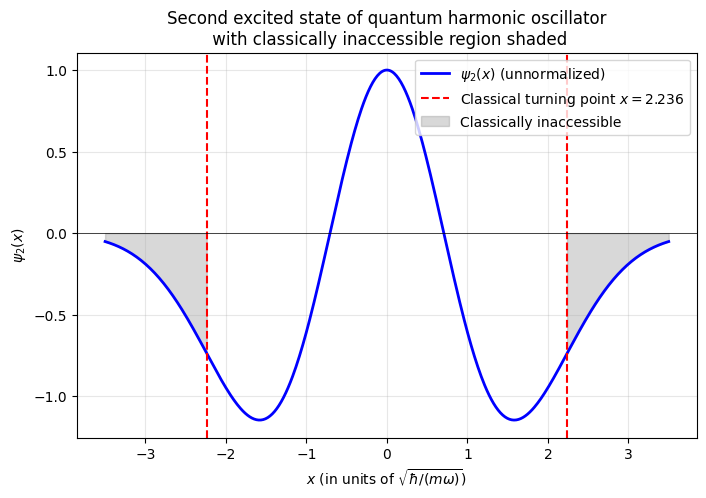

In [ ]:
#importing necessary libraries


import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.optimize import newton   # newton raphson method for root finding (MIGHT BE USEFUL LATER)





#### Creating the main function:
Solving Kepler's equation is a key step in determining the radial velocities of a star induced by an exoplanet orbiting it. It allows the orbital position of a planet to be calculated as a function of time. 
Kepler's equation is given by:  
<centre> $$   E - e \cdot \sin E  = M \;\;\;\;\;\; (1) $$ </centre>  Where E is the eccentric anomaly, e is eccentricity and M is the mean anomaly  
    
The code cell below contains the main function used to solve Kepler's equation. The parameters the function takes are:
* M - The mean anomaly  
* e - The eccentricity  
* tol - the Convergence tolerance
* nittermax - The max amount of times Newton-Raphson method will loop for.

For the root finding method to be applied, Kepler's equation is rearranged into the form:
<centre> $$ f(E) = E - e \cdot \sin E - M  \;\;\;\;\;\; (2)  $$ </centre>
with the derivative form:
<centre> $$ f'(E) = 1 - e \cdot \cos E \;\;\;\;\;\; (3) $$ </centre> 
  

These two functions are used in the Newton-Raphson root finding process:
<centre> $$ E_{n+1}  = E_n  - \frac{f(E_n)}{f'(E_n)} \;\;\;\;\;\; (4) $$  </centre>

For each value of M (mean anomaly), an initial guess $ E_0 $ was deduced based on the eccentricity. The iteration is repeated until the absolute residual , $ | f(E) | $ falls below the tolerance or until the max amount of 30 iterations has been reached.

In [19]:
#solving kepler's equation using newton raphson method (MAIN FUNCTION)

def kepler_equation(M, e, tol=1e-12, nittermax=30):
    
    # creating a numpy array to hold eccentric anomaly values
    E_vals = []

    # Define the function and its derivative
    def f(E):
        return E - e * np.sin(E) - M

    def f_prime(E):
        return 1 - e * np.cos(E)

    
    for M in M:

    # Initial guess for E
        E0 = M if e < 0.8 else np.pi # for high eccentricities, start at pi for better convergence. at low eccentricities, E ~ M
        iteration = 0

        E = E0
        # Use Newton-Raphson method to find the root
        while abs(f(E)) > tol and iteration < nittermax:
            E = E - (f(E) / f_prime(E))
            iteration += 1
        E_vals.append(E)


    return E_vals




#same function but using the newton method from scipy library

def kepler_equation_newton(M, e, tol=1e-12, nittermax=30):
    
    # creating a numpy array to hold eccentric anomaly values
    E_vals = []

    # Define the function and its derivative
    def f(E):
        return E - e * np.sin(E) - M

    def f_prime(E):
        return 1 - e * np.cos(E)

    
    for M in M:

        # Initial guess for E
        E0 = M if e < 0.8 else np.pi # for high eccentricities, start at pi for better convergence. at low eccentricities, E ~ M

        # Use scipy's newton method to find the root
        E = newton(f, E0, fprime=f_prime, tol=tol, maxiter=nittermax)
        E_vals.append(E)


    return E_vals



    


#### Generating orbital values for time:

In order to utilise the function to solve Kepler's equation, a set of functions was implemented to create the required orbital values from time. These functions allow a uniform temporal sampling of the planets orbit to be generated and provide the necessary input for the Kepler solver function.

A uniform time array is generated containing roughly ten sample points per day. The time array is then used to compute a list of mean anomaly values, which serve as the main argument for the Kepler equation solver. A for loop is used to carry out the creation of these two list.  
The formula to convert time to mean anomaly is : 
<centre> $$ M(t) = n \cdot t = \frac{2 \pi }{P} \cdot t \;\;\;\;\;\; (5) $$  </centre> 
Where n is the unifrom angular rate swept out per unit time and P is the orbital period in days.  

In [20]:

#getting the time array
def time_array(P,n= 10):
    
    time_array = []
    for i in range(int(n*P)):
        time_array.append(0.1*i)
    return time_array

#getting the mean anomaly from time 
def mean_anomaly(t, P):
   
    n = 2 * np.pi / P  # mean motion per day 
    M = []  # initialize mean anomaly array
    for time in t:
        M.append(n * time)
    return M


##### Converting to true anomaly and calculating the radial velocity:

After Kepler's equation has been solved to obtain the eccentric anomaly values E, greater transformations must be applied to E in order to compute the radial velocity of the host star. The eccentric anomaly must be converted to the true anomaly which directly describes the angular position of the planet during its orbit.  
The conversion from eccentric anomaly to true anomaly is:
<centre> $$ f = 2 \cdot \arctan \frac{\sqrt{1+ e } \cdot \sin \frac {E}{2} }{\sqrt 1 -e \cdot \cos \frac {E}{2}} \;\;\;\;\;\; (6) $$  </centre> 
where f is the true anomaly, e is the orbital eccentricity and E is the eccentric anomaly. the arctan2 function is used ensure the correct quadrant is used for the true anomaly so there are no discontinuities in the orbit. This is done by taking two arguments, a numerator and a denominator. This conversion is applied to each element in the eccentric anomaly list to gain a new true anomaly list.

The true anomaly is then used to compute the radial velocity of the star due to the orbiting exoplanet. The radial velocity is calculated using the expression:
<centre> $$ v_r = K \cdot [ \cos (f+ \omega) + e \cos \omega] \;\;\;\;\;\; (7) $$  </centre> 
where $ v_r $ is the radial velocity, K is the radial velocity semi-major amplitude and $ \omega $ is argument of the node. The equation accounts for instantaneous orbital phase of the planet and the eccentricity of the orbit.The derivation for the forumlas (6) and (7) are influenced from [3]. The radial velocity is evaluated for each true anomaly value thus, a radial velocity list must also be returned from the function.

In [21]:

#eccentric to anomaly conversion function
def eccentric_to_true_anomaly(E, e):
    #eccentricity of the orbit
    
    f_list = []
    for E in E:

        f = 2 * np.arctan2(np.sqrt(1 + e) * np.sin(E / 2), np.sqrt(1 - e) * np.cos(E / 2)) # numerator and denominator form to get correct quadrant
        f_list.append(f)
    return f_list


#getting radial velocity from true anomaly
def radial_velocity(f, K = 1, omega = 0.2, e =0.6):

    RV_list = []
    for f in f:

        RV = K * (np.cos(f + omega) + e * np.cos(omega))
        RV_list.append(RV)
    return RV_list




##### Testing the functions:

The code below is simply put together to ensure the functions that were created returns appropriate values. This part isn't neccasary but it is useful for determining errors in code. 

In [22]:
#testing the functions

#using kepler's equation to get eccentric the true anomaly
times = time_array(20)
print(times)
eccentric_anomaly =  kepler_equation(mean_anomaly(times,20),0.6)
print(eccentric_anomaly)

#getting the true anomaly
true_anomaly =  eccentric_to_true_anomaly(eccentric_anomaly,0.6)
print(true_anomaly)

#getting the radial velocity
radial_V = radial_velocity(true_anomaly)

print(radial_V)



[0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6000000000000001, 0.7000000000000001, 0.8, 0.9, 1.0, 1.1, 1.2000000000000002, 1.3, 1.4000000000000001, 1.5, 1.6, 1.7000000000000002, 1.8, 1.9000000000000001, 2.0, 2.1, 2.2, 2.3000000000000003, 2.4000000000000004, 2.5, 2.6, 2.7, 2.8000000000000003, 2.9000000000000004, 3.0, 3.1, 3.2, 3.3000000000000003, 3.4000000000000004, 3.5, 3.6, 3.7, 3.8000000000000003, 3.9000000000000004, 4.0, 4.1000000000000005, 4.2, 4.3, 4.4, 4.5, 4.6000000000000005, 4.7, 4.800000000000001, 4.9, 5.0, 5.1000000000000005, 5.2, 5.300000000000001, 5.4, 5.5, 5.6000000000000005, 5.7, 5.800000000000001, 5.9, 6.0, 6.1000000000000005, 6.2, 6.300000000000001, 6.4, 6.5, 6.6000000000000005, 6.7, 6.800000000000001, 6.9, 7.0, 7.1000000000000005, 7.2, 7.300000000000001, 7.4, 7.5, 7.6000000000000005, 7.7, 7.800000000000001, 7.9, 8.0, 8.1, 8.200000000000001, 8.3, 8.4, 8.5, 8.6, 8.700000000000001, 8.8, 8.9, 9.0, 9.1, 9.200000000000001, 9.3, 9.4, 9.5, 9.600000000000001, 9.700000000000

#####   Plotting the RV curve:

Pyplot from the library "MatPlotLib" is used to generate graphs for radial velocity against time and radial velocity against the true anomaly. Graphs are useful as they allow for detailed interpretations of the values attained.

Text(0.5, 1.0, 'Radial Velocity vs True Anomaly [1.2]')

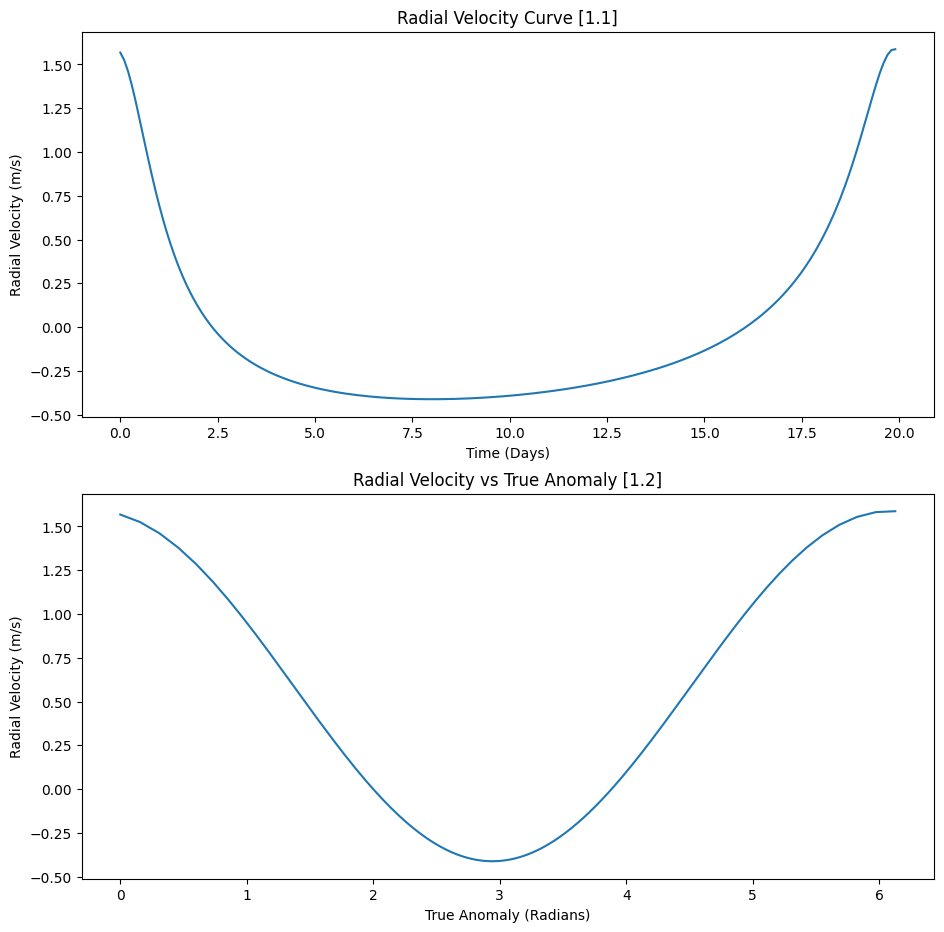

In [23]:
#plotting the radial velocity curve
#time against radial velocity
plt.figure(figsize=(11,11))
plt.subplot(2,1,1)
plt.plot(times,radial_V)
plt.xlabel('Time (Days)')
plt.ylabel('Radial Velocity (m/s)')
plt.title('Radial Velocity Curve [1.1]')

#anomaly against radial velocity
plt.subplot(2,1,2)
plt.plot(true_anomaly,radial_V)
plt.xlabel('True Anomaly (Radians)')
plt.ylabel('Radial Velocity (m/s)')
plt.title('Radial Velocity vs True Anomaly [1.2]')



##### Residual error calculation:
To ensure that our values of eccentric anomaly (E) attained from the Newton-Raphson method are close to the actual value, a function is created to get residuals. The function uses the list of E values and enters that value into equation (1). The returned value is the residual, and it is stored in a residual list to check the properties of the residuals. If the residuals are below the tolerance level, this indicates that the Newton-Raphson function works as intended.

In [24]:
#risidual error calculation

def calculate_residual_error(M, E_solution, e):
    
    residual = np.abs(E_solution - e * np.sin(E_solution) - M)  #calculating the residual error 
    return residual

residuals = calculate_residual_error(mean_anomaly(times,20), eccentric_anomaly, e=0.6) #residuals list
print(f"Max residual: {residuals.max():.2e}")  #2 decimal places
print(f"Mean residual: {residuals.mean():.2e}")
print(f"All residuals < 1e-12? {np.all(residuals < 1e-12)}")  # checking if all residuals are below the tolerance level of 1e-12

#shows that the errors are within exceptable limits


#finding the residuals using the newton method from scipy and comparing with my method

residuals_newton = calculate_residual_error(mean_anomaly(times,20), kepler_equation_newton(mean_anomaly(times,20),0.6), e=0.6) #residuals list
print(f"Max residual (Newton): {residuals_newton.max():.2e}")  #2 decimal places
print(f"Mean residual (Newton): {residuals_newton.mean():.2e}")
print(f"All residuals < 1e-12 (Newton)? {np.all(residuals_newton < 1e-12)}")  # checking if all residuals are below the tolerance level of 1e-12





Max residual: 6.88e-13
Mean residual: 4.13e-14
All residuals < 1e-12? True
Max residual (Newton): 8.88e-16
Mean residual (Newton): 8.94e-17
All residuals < 1e-12 (Newton)? True


#### Convergence testing:

The code below checks the amount of iterations needed per mean anomaly value. It outputs a list of iterations required instead of a list of E values.

In [25]:
#convergence testing 

#same function but returning number of iterations needed for convergence

def kepler_equation_conv(M, e, tol=1e-12, nittermax=30):
    
    # creating a numpy array to hold eccentric anomaly values
    E_vals = []

    # Define the function and its derivative
    def f(E):
        return E - e * np.sin(E) - M

    def f_prime(E):
        return 1 - e * np.cos(E)

    iterations_needed = []
    
    for M in M:

    # Initial guess for E
        E0 = M if e < 0.8 else np.pi # for high eccentricities, start at pi for better convergence. at low eccentricities, E ~ M
        iteration = 0

        E = E0
        # Use Newton-Raphson method to find the root
        while abs(f(E)) > tol and iteration < nittermax:
            E = E - (f(E) / f_prime(E))
            iteration += 1
        E_vals.append(E)
        iterations_needed.append(iteration)


    return iterations_needed


#same function but using the newton method from scipy library

def kepler_equation_newton_conv(M, e, tol=1e-12, nittermax=30):
    
    # creating a numpy array to hold eccentric anomaly values
    E_vals = []

    # Define the function and its derivative
    def f(E):
        return E - e * np.sin(E) - M

    def f_prime(E):
        return 1 - e * np.cos(E)

    iterations_needed = []

    for M in M:

        # Initial guess for E
        E0 = M if e < 0.8 else np.pi # for high eccentricities, start at pi for better convergence. at low eccentricities, E ~ M

        # Use scipy's newton method to find the root
        E, result = newton(f, E0, fprime=f_prime, tol=tol, maxiter=nittermax, full_output=True)
        E_vals.append(E)
        iterations_needed.append(result.iterations) 


    return iterations_needed



#### Calculating differences in mean residual and convergence speed:

The code cell below is used to print the diffences in mean residual and iteration numbers.

In [26]:
difference_in_residuals = residuals.mean() - residuals_newton.mean()
print(f"Difference in mean residuals between methods: {difference_in_residuals:.2e}")

#testing the convergence functions
iterations_my_method = kepler_equation_conv(mean_anomaly(times,20),0.6)
iterations_newton_method = kepler_equation_newton_conv(mean_anomaly(times,20),0.6)
iteration_diff = np.array(iterations_my_method) - np.array(iterations_newton_method)
print(f"Iteration differences between methods: {iteration_diff}")
average_iterations_diff = np.mean(iteration_diff)
print(f"Average iteration difference: {average_iterations_diff}")

Difference in mean residuals between methods: 4.12e-14
Iteration differences between methods: [ 0 -1 -1 -1 -1 -1 -1  0 -1 -1 -1 -1 -1 -1 -1  0  0  0 -1  0  0  0  0 -1
  0 -1  0 -1  0 -1 -1 -1  0 -1  0  0  0  0 -1  0 -1 -1  0 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  0 -1  0  0 -1 -1  0 -1  0  0  0 -1
  0  0  0  0  0  0 -1  0 -1 -1 -1 -1 -1 -1 -1 -1  0  0  0 -1 -1  0  0 -1
  0  0 -1 -1  0 -1 -1 -1 -1 -1  0 -1  0 -1  0  0 -1 -1 -1 -1 -1 -1 -1 -1
 -1  0  0  0  0  0  0  0  0  0  0  0 -1  0 -1  0  0  0  0 -1  0  0  0 -1
 -1  0 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  0  0  0  0  0  0 -1  0  0  0
  0  0  0  0 -1  0  0  0  0 -1  0  0  0 -1  0  0  0  0  0 -1 -1 -1 -1 -1
  0  0  0  0  0 -1  0  0]
Average iteration difference: -0.515


Max residual: 9.81e-13
Mean residual: 4.74e-14
All residuals < 1e-12? True


Text(0.5, 1.0, 'Radial Velocity vs True Anomaly - high eccentricity [2.2]')

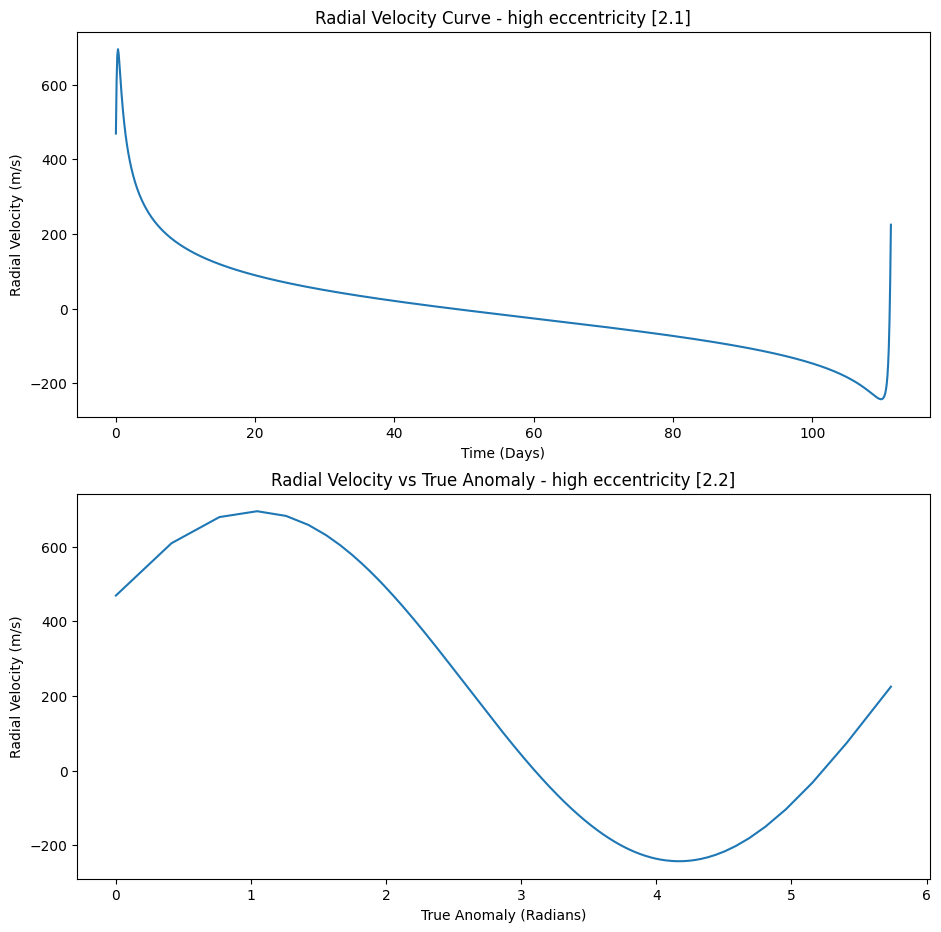

In [27]:
#testing the functions using real-life data
# data is from the Nasa exoplanet archive [4]

#HIGH ECCENTRICITY EXOPLANET DATA  all variables are distignuished using 'high_' prefix

#planets name : HD 80606 b  
#eccentricity : 0.93
#period : 111.436 days
#semi-amplitude K : 469.22 +- 0.61 m/s
#argument of periastron omega : 301.213 +- (0.043) = 5.257 +- (0.0008) radians

#using kepler's equation to get eccentric the true anomaly
high_times = time_array(111.436)
high_eccentric_anomaly =  kepler_equation(mean_anomaly(high_times,111.436),0.93)

#getting the true anomaly
high_true_anomaly =  eccentric_to_true_anomaly(high_eccentric_anomaly,0.93)

#getting the radial velocity
high_radial_V = radial_velocity(high_true_anomaly, K = 469.22, omega = 5.257, e =0.93)


high_residuals = calculate_residual_error(mean_anomaly(high_times,111.436), high_eccentric_anomaly, e=0.93) #residuals list
print(f"Max residual: {high_residuals.max():.2e}")
print(f"Mean residual: {high_residuals.mean():.2e}")
print(f"All residuals < 1e-12? {np.all(high_residuals < 1e-12)}")  # checking if all residuals are below the tolerance level of 1e-12

#shows that the errors are within exceptable limits


#plotting the radial velocity curve
#time against radial velocity
plt.figure(figsize=(11,11))
plt.subplot(2,1,1)
plt.plot(high_times,high_radial_V)
plt.xlabel('Time (Days)')
plt.ylabel('Radial Velocity (m/s)')
plt.title('Radial Velocity Curve - high eccentricity [2.1]')

#anomaly against radial velocity
plt.subplot(2,1,2)
plt.plot(high_true_anomaly,high_radial_V)
plt.xlabel('True Anomaly (Radians)')
plt.ylabel('Radial Velocity (m/s)')
plt.title('Radial Velocity vs True Anomaly - high eccentricity [2.2]')


Max residual: 9.83e-13
Mean residual: 1.85e-14
All residuals < 1e-12? True


Text(0.5, 1.0, 'Radial Velocity vs True Anomaly - low eccentricity [3.2]')

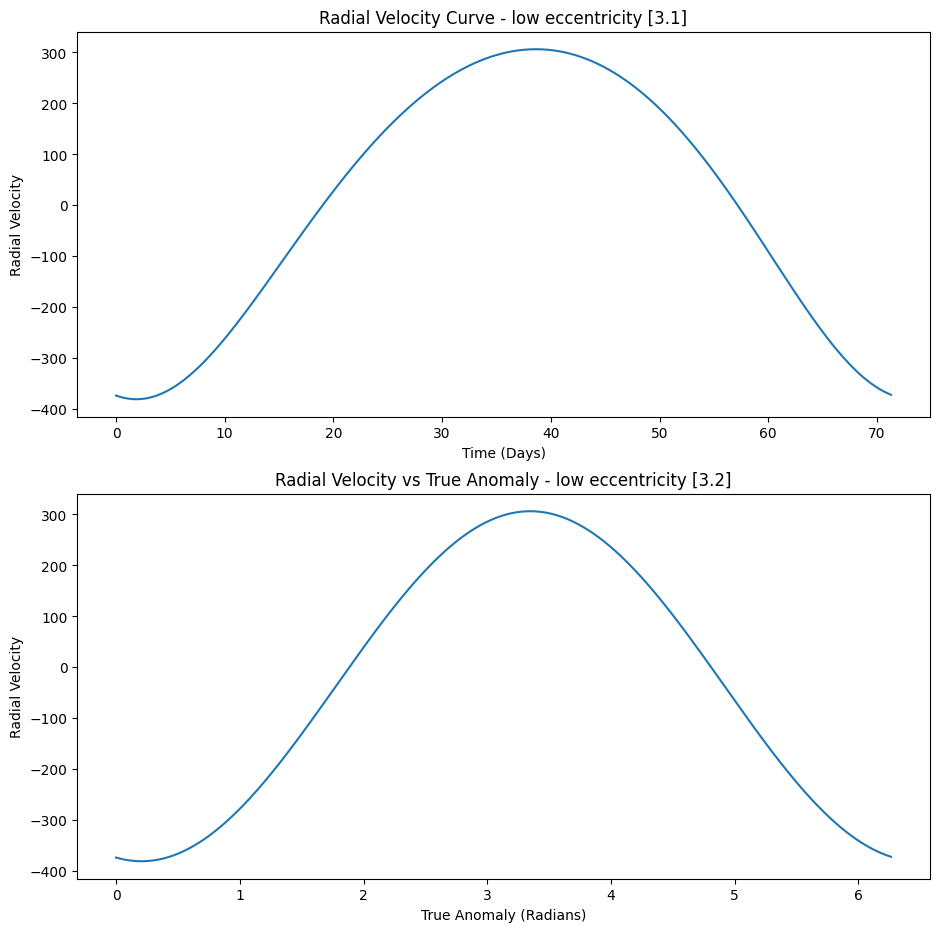

In [28]:
#testing the functions using real-life data
# data is from the Nasa exoplanet archive [4]

#LOW ECCENTRICITY EXOPLANET DATA  all variables are distignuished using 'low_' prefix

#planets name : HD 178911 B b
#eccentricity : 0.11
#period : 71.484 days
#semi-amplitude K : 343.3 +- 1 m/s
#argument of periastron omega : 168.2 +- 1.6 degrees = 2.936 +- 0.017 radians

#using kepler's equation to get eccentric the true anomaly
low_times = time_array(71.484)
low_eccentric_anomaly =  kepler_equation(mean_anomaly(low_times,71.484),0.11)

#getting the true anomaly
low_true_anomaly =  eccentric_to_true_anomaly(low_eccentric_anomaly,0.11)

#getting the radial velocity
low_radial_V = radial_velocity(low_true_anomaly, K = 343.3, omega = 2.936  , e =0.11)


low_residuals = calculate_residual_error(mean_anomaly(low_times,71.484), low_eccentric_anomaly, e=0.11) #residuals list
print(f"Max residual: {low_residuals.max():.2e}")
print(f"Mean residual: {low_residuals.mean():.2e}")
print(f"All residuals < 1e-12? {np.all(low_residuals < 1e-12)}")  # checking if all residuals are below the tolerance level of 1e-12

#shows that the errors are within exceptable limits


#plotting the radial velocity curve
#time against radial velocity
plt.figure(figsize=(11,11))
plt.subplot(2,1,1)
plt.plot(low_times,low_radial_V)
plt.xlabel('Time (Days)')
plt.ylabel('Radial Velocity')
plt.title('Radial Velocity Curve - low eccentricity [3.1]')

#anomaly against radial velocity
plt.subplot(2,1,2)
plt.plot(low_true_anomaly,low_radial_V)
plt.xlabel('True Anomaly (Radians)')
plt.ylabel('Radial Velocity')
plt.title('Radial Velocity vs True Anomaly - low eccentricity [3.2]')

## Results:
Both methods converge to a consistent solution within the specified tolerence. The SciPy function produces a marginally smaller residual than the custom implementation used in this project. The differences are:  
Difference in mean residuals between methods: $4.12 \times 10^{-14}$  
Average iteration difference: $-0.515$


The Newton-Raphson method was used to compute the radial velocity signal induced by an exoplanet for a multitude of orbital eccentricities and parameters. Radial velocity curves were generated as a function of time and a function of true anomaly, allowing the effects of the parameters to be examined. The exoplanetary data were acquired from the NASA archive [4] and are visible in the code cells used to simulate each system. 


#### Low eccentricity system:


For low eccentricity values, the radial velocity curve exhibits a smooth, approximately sinusoidal shape when plotted against time, as seen in Figure 3.1. The radial velocity's maxima and minima appear at regular intervals and remain constant throughout the orbit. This behaviour is characteristic of near-circular orbits, where the orbital speed of the exoplanet remains nearly constant throughout the orbit. The velocity semi-amplitude, K, acts as a linear scaling factor for the magnitude of the radial velocity signal. 



When plotted against true anomaly, the radial velocity curve retains its symmetry as seen in Figure 3.2. The absence of sharp features suggests the stellar reflex motion ("wobble") is almost uniform throughout its orbital period. The behaviour of this system aligns well with the idea of a near-circular orbit.




#### High eccentricity system:
In contrast, the high eccentricity system produces a markedly asymmetric radial velocity curve. The curve in Figure 2.1 contains a sharp spike of radial velocity in a small time frame. This feature corresponds to the planet's passage through periastron. This occurs because of the exoplanet's orbital velocity drastically changing when it is closest to the star. For the rest of the orbit, the radial velocity varies slowly and has a long, shallow tail. This indicates that the planet is passing near the apastron, where the velocity is much slower during this period. This behaviour represents a strong divergence from sinusoidal motion due to the high eccentricity.




#### Effect of the argument of Periastron:
The argument of periastron $ \omega $ determines the orientation of the orbit relative to the observer. It plays an important role in shaping the observed radial velocity signal, especially for eccentric systems.  
The low eccentricity system's value of the argument of periastron is :  
<centre> $$ \omega = 168.2 \degree \pm 1.6 \degree $$  </centre>



Due to the small eccentricity value, the effect of the term $ e \cos \omega $ in equation (7) was very small, and its effect on the value was negligible. Thus, $ \omega $ only affected the phase in the radial velocity curve. The signal remained almost sinusoidal and symmetric. This demonstrates that $ \omega $ has little to no observable impact in low eccentricity systems.    


In contrast, for the system with high eccentricity:
<centre> $$ \omega = 301.213 \degree \pm 0.043 \degree $$  </centre>  
The effect of the argument of periastron is significantly more prominent. In this system, periastron occurs when the exoplanet is moving towards the observer, resulting in a strong radial velocity over a short time interval. This causes an asymmetry in the radial curve due to the sharp peak near the periastron and a long, shallow tail when the exoplanet is near the apastron.  
Additionally, the non-zero eccentricity causes a vertical offset due to the $ e \cos \omega $ term in equation (7). This causes there to be a difference in magnitude for the maxima and minima velocities.
Overall, these results show that the argument of periastron has a small observational impact for low eccentricity systems but significantly alters the shape of a high eccentricity radial velocity curve.


## Discussion:

Both Newton-Raphson root finding method converged to consistent solutions, with Scipy method producing a marginally smaller residual by $ 4.12 \times 10^{-14}   $  compared to the custom implementation. However, the Scipy function was slower at converging by an average of $0.515$ iterations and was therefore not used to solve observed exoplanetary systems. 

The results obtained demonstrate that the numerical solution of Kepler's equation can be used to accurately model the radial velocity signal induced by an exoplanet for a multitude of eccentric systems. By applying the Newton-Raphson method, realistic radial velocity curves were produced that contain both near sinusoidal behaviour from low eccentricity orbits and asymmetric features from high eccentricity orbits.


The numerical accuracy is heavily dependent on the convergence of the Newton-Raphson method. For both tested systems, the residual of Kepler's equation remained below the chosen tolerance level of $ 10^{-12} $, indicating that the error from the root finding process is negligible and therefore does not contribute significantly to the structure of the radial velocity curves compared to the physical effects being modelled. Both tests took less than 30 iterations to converge to an appropriate value of E. This result was aided by the eccentricity-dependent initial guess system in the root finding function to converge even when the eccentricity is high. The exoplanets in the high and low eccentric systems were chosen as they had negligible error in their eccentricities. However, they had up to 0.95% error in the argument of periastron and up to 0.29% error in the velocity semi-amplitude.  


While numerical errors are small, other types of uncertainties remain. The model assumes a single-planet system with a fixed Keplerian orbit. Uncertainties emerge due to the neglect of other gravitational interactions that occur within multi-planet systems. Furthermore, non-Keplerian effects, such as relativistic effects, despite having very little effect, still contribute to the uncertainties in the planet's orbital motion.  
 
The figures attained give us the backbone needed to suggest that there is a strong dependence of the radial velocity signal on orbital eccentricity and orientation. Low eccentric orbits produce smooth, symmetric radial velocity curves that appear sinusoidal, while high eccentricity systems contain sharp spikes in velocity near periastron. The role the argument of the periastron, $ \omega $, plays depends on the eccentricity of the orbit. Nonetheless, $ \omega $ is important for accurately modelling orbital geometry when interpreting radial velocity data.  

Overall, this project shows that numerical solutions to Kepler's equation provide a robust framework for modelling exoplanet-induced radial velocity signals. The results emphasise that, despite numerical precision being achieved to a high degree, physical assumptions heavily limit the accuracy of the orbital model due to the dominance of real-life uncertainties.


## Conclusion:  

In this project, Kepler's equation was solved numerically using the Newton-Raphson method. This method was implemented with high accuracy and efficiency due to the adaptive use of computational methods. Kepler's equation allowed for a model of the radial velocity signal induced by an exoplanet orbiting a host star. The combination of numerical root finding and orbital geometry enabled the generation of successful radial velocity curves as functions of time and true anomaly for systems with varying orbital eccentricities.  
 
The results demonstrated that the numerical approach is accurate and robust, with residual errors below the tolerance level. This confirms that the Newton-Raphson method provides a reliable solution across both low and high-eccentricity systems due to the eccentricity-based initial guess system. The radial velocity curves produced imitate the physical behaviour of near circular orbits, smooth, approximately sinusoidal signals, and high eccentric orbits, exhibiting strong asymmetries and sharp variations in velocity near periastron.  

The influence of the argument of periastron was dependent on the eccentricity of the system. For low eccentricity systems, it merely acted as a phase difference, whereas for high eccentricity systems, it drastically affects the shape and symmetry of the curve. This emphasises the importance of accurately modelling orbital orientation to achieve accurate radial velocity signals.   

While the model successfully captures the features of exoplanet-induced radial velocity signals, it is limited by the assumption of a single-planet, Keplerian system. Additional effects such as multi-planet gravitational interactions and relativistic effects were neglected and introduce further uncertainties in real observational data. Nonetheless, the methodology used provides a strong foundation for modelling and interpreting radial velocity signals and demonstrates the effectiveness of numerical and computational methods in exoplanet detection and characterisation.  



## References:

[1]: science.nasa.gov. (2019). Nobel Winners Changed Our Understanding with Exoplanet Discovery - NASA Science. [online] Available at: https://science.nasa.gov/universe/exoplanets/nobel-winners-changed-our-understanding-with-exoplanet-discovery/.  
  
[2]: NASA (2024). Exoplanets. [online] science.nasa.gov. Available at: https://science.nasa.gov/exoplanets/.  

[3]: Physics LibreTexts. (2017). 18.2: The Velocity Curve from the Elements. [online] Available at: https://phys.libretexts.org/Bookshelves/Astronomy__Cosmology/Celestial_Mechanics_(Tatum)/18%3A_Spectroscopic_Binary_Stars/18.02%3A_The_Velocity_Curve_from_the_Elements

[4]: exoplanetarchive.ipac.caltech.edu. (n.d.). Planetary Systems. [online] Available at: https://exoplanetarchive.ipac.caltech.edu/cgi-bin/TblView/nph-tblView?app=ExoTbls&config=PS. 


